# Hartmann 6D: analysis of 10 SMAC runs

This notebook loads all SMAC components with `master_utils.reload_components.load_smac_components` and compares incumbent performance across seeds.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "master_utils").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from master_utils.reload_components import load_smac_components

RESULTS_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "hartmann"
    / "02_first_experiments"
    / "hartmann_6d_10seeds"
)
SEEDS = range(10)
HARTMANN_6D_MINIMUM = -3.322368011415515
CONFIDENCE = 0.95

plt.rcParams.update({"figure.figsize": (9, 5.5), "axes.grid": True})

## Load runs and construct incumbent trajectories

In [2]:
runs = {
    seed: load_smac_components(RESULTS_DIR / str(seed))
    for seed in SEEDS
}


def incumbent_trajectory(runhistory):
    trials = sorted(
        runhistory.items(),
        key=lambda item: item[1].starttime,
    )
    costs = np.asarray([value.cost for _, value in trials], dtype=float)
    return np.minimum.accumulate(costs)


trajectories = {
    seed: incumbent_trajectory(components["runhistory"])
    for seed, components in runs.items()
}
run_lengths = {seed: len(values) for seed, values in trajectories.items()}
assert min(run_lengths.values()) >= 500, run_lengths

n_trials = min(run_lengths.values())
trial_numbers = np.arange(1, n_trials + 1)
incumbent_costs = np.vstack([trajectories[seed][:n_trials] for seed in SEEDS])
run_lengths

{0: 500,
 1: 500,
 2: 500,
 3: 500,
 4: 500,
 5: 500,
 6: 500,
 7: 500,
 8: 500,
 9: 500}

In [3]:
def mean_and_ci(values, confidence=CONFIDENCE):
    values = np.asarray(values, dtype=float)
    mean = values.mean(axis=0)
    sem = values.std(axis=0, ddof=1) / np.sqrt(values.shape[0])
    critical_value = t.ppf((1 + confidence) / 2, df=values.shape[0] - 1)
    half_width = critical_value * sem
    return mean, mean - half_width, mean + half_width

## 1a. Final incumbent cost

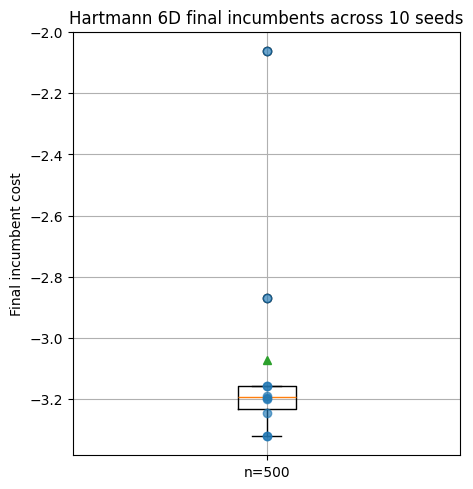

In [4]:
final_incumbent_costs = incumbent_costs[:, -1]

fig, ax = plt.subplots(figsize=(5, 5.5))
ax.boxplot(final_incumbent_costs, tick_labels=[f"n={n_trials}"], showmeans=True)
ax.scatter(np.ones(len(final_incumbent_costs)), final_incumbent_costs, alpha=0.65, zorder=3)
ax.set_ylabel("Final incumbent cost")
ax.set_title("Hartmann 6D final incumbents across 10 seeds")
plt.show()

## 1b. Incumbent cost after 200, 300, 400, and 500 trials

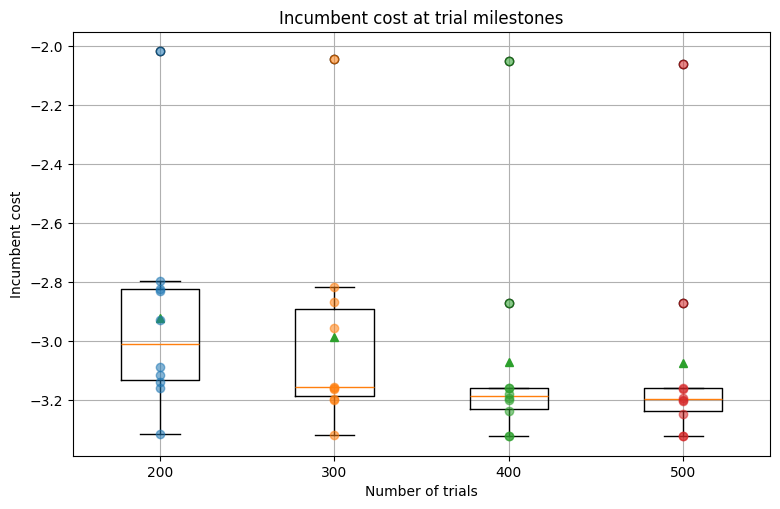

In [5]:
milestones = [200, 300, 400, 500]
milestone_costs = [incumbent_costs[:, n - 1] for n in milestones]

fig, ax = plt.subplots()
ax.boxplot(milestone_costs, tick_labels=milestones, showmeans=True)
for position, values in enumerate(milestone_costs, start=1):
    ax.scatter(np.full(len(values), position), values, alpha=0.55, zorder=3)
ax.set_xlabel("Number of trials")
ax.set_ylabel("Incumbent cost")
ax.set_title("Incumbent cost at trial milestones")
plt.show()

## 2. Mean best-so-far cost with 95% confidence interval

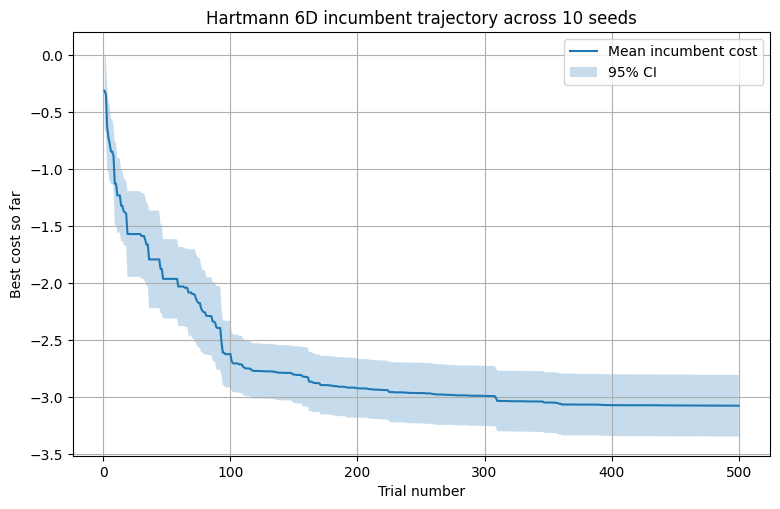

In [6]:
mean_cost, cost_ci_lower, cost_ci_upper = mean_and_ci(incumbent_costs)

fig, ax = plt.subplots()
ax.plot(trial_numbers, mean_cost, label="Mean incumbent cost")
ax.fill_between(
    trial_numbers,
    cost_ci_lower,
    cost_ci_upper,
    alpha=0.25,
    label="95% CI",
)
ax.set_xlabel("Trial number")
ax.set_ylabel("Best cost so far")
ax.set_title("Hartmann 6D incumbent trajectory across 10 seeds")
ax.legend()
plt.show()

## 3. Best-so-far cost for every run

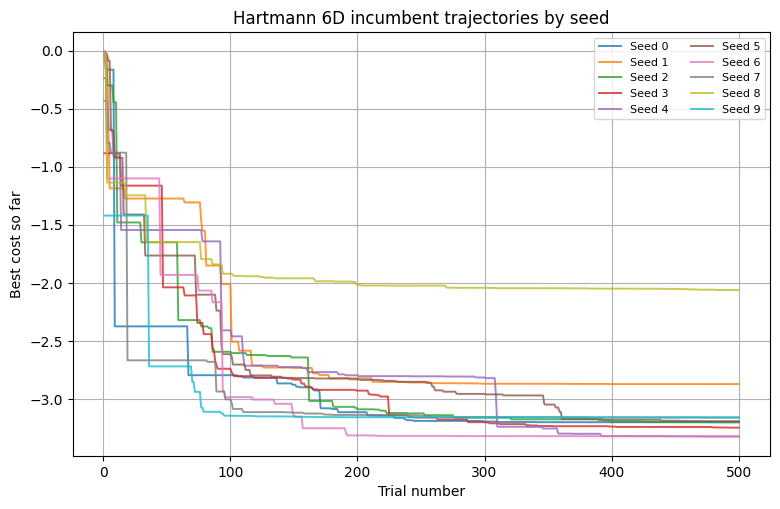

In [7]:
fig, ax = plt.subplots()
for seed, costs in zip(SEEDS, incumbent_costs):
    ax.plot(trial_numbers, costs, alpha=0.8, linewidth=1.4, label=f"Seed {seed}")
ax.set_xlabel("Trial number")
ax.set_ylabel("Best cost so far")
ax.set_title("Hartmann 6D incumbent trajectories by seed")
ax.legend(ncol=2, fontsize=8)
plt.show()

## 4. Simple regret on a logarithmic scale

Simple regret is $f(x_t^*) - f(x^*)$, using the known Hartmann-6 minimum $f(x^*) = -3.322368011415515$.

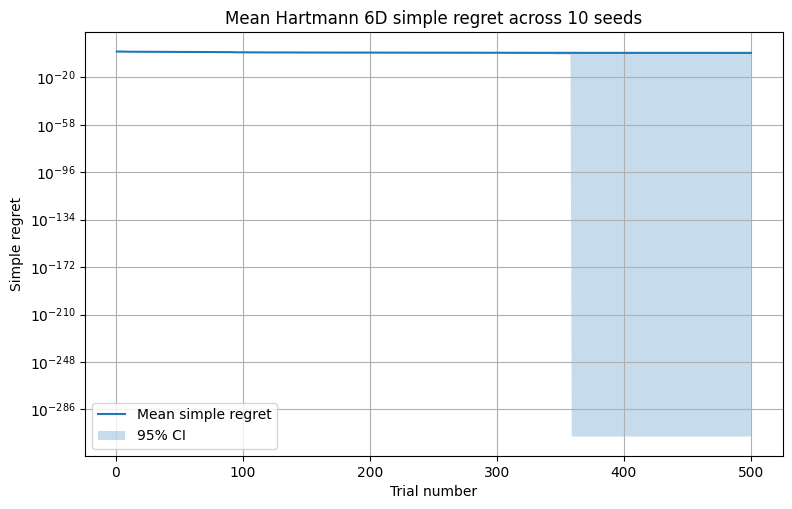

In [8]:
simple_regret = incumbent_costs - HARTMANN_6D_MINIMUM
mean_regret, regret_ci_lower, regret_ci_upper = mean_and_ci(simple_regret)
positive_floor = np.finfo(float).tiny

fig, ax = plt.subplots()
ax.plot(trial_numbers, mean_regret, label="Mean simple regret")
ax.fill_between(
    trial_numbers,
    np.maximum(regret_ci_lower, positive_floor),
    regret_ci_upper,
    alpha=0.25,
    label="95% CI",
)
ax.set_yscale("log")
ax.set_xlabel("Trial number")
ax.set_ylabel("Simple regret")
ax.set_title("Mean Hartmann 6D simple regret across 10 seeds")
ax.legend()
plt.show()

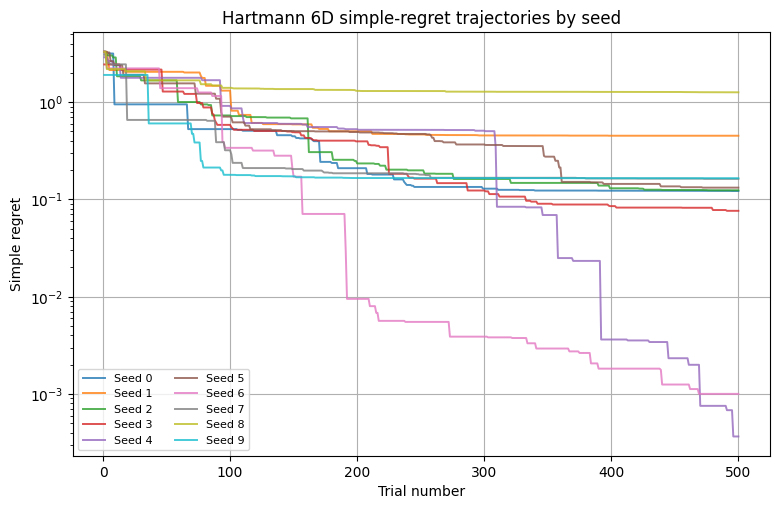

In [9]:
fig, ax = plt.subplots()
for seed, regrets in zip(SEEDS, simple_regret):
    ax.plot(trial_numbers, regrets, alpha=0.8, linewidth=1.4, label=f"Seed {seed}")
ax.set_yscale("log")
ax.set_xlabel("Trial number")
ax.set_ylabel("Simple regret")
ax.set_title("Hartmann 6D simple-regret trajectories by seed")
ax.legend(ncol=2, fontsize=8)
plt.show()

## 5. Final incumbent configuration and regret by seed

`simple_regret` reports regret on its original scale; `log10_simple_regret` reports its base-10 logarithm, matching the orders of magnitude shown on the logarithmic plots.

In [10]:
incumbent_rows = []
for seed, components in runs.items():
    incumbent = components["intensifier"].get_incumbent()
    incumbent_cost = components["runhistory"].get_cost(incumbent)
    regret = incumbent_cost - HARTMANN_6D_MINIMUM
    incumbent_rows.append(
        {
            "seed": seed,
            **dict(incumbent),
            "incumbent_cost": incumbent_cost,
            "simple_regret": regret,
            "log10_simple_regret": np.log10(max(regret, np.finfo(float).tiny)),
        }
    )

incumbent_summary = pd.DataFrame(incumbent_rows).sort_values("seed")
incumbent_summary.style.format(
    {
        **{f"x{i}": "{:.6f}" for i in range(1, 7)},
        "incumbent_cost": "{:.9f}",
        "simple_regret": "{:.9f}",
        "log10_simple_regret": "{:.4f}",
    }
)

,seed,x1,x2,x3,x4,x5,x6,incumbent_cost,simple_regret,log10_simple_regret
0,0,0.404780,0.881871,0.857724,0.570227,0.052130,0.039072,-3.200338748,0.122029263,-0.9135
1,1,0.404084,0.999490,0.853597,0.573043,0.147003,0.039063,-2.871113215,0.451254796,-0.3456
2,2,0.406784,0.884449,0.989560,0.573248,0.061712,0.039074,-3.198217691,0.124150320,-0.9061
3,3,0.209375,0.068820,0.483507,0.272550,0.314065,0.660735,-3.246011976,0.076356035,-1.1172
4,4,0.202159,0.150056,0.479577,0.278272,0.311074,0.657580,-3.322001820,0.000366192,-3.4363
5,5,0.398348,0.889684,0.715343,0.578999,0.067447,0.028802,-3.190220943,0.132147068,-0.8789
6,6,0.193015,0.152195,0.477133,0.274224,0.311880,0.657299,-3.321364334,0.001003678,-2.9984
7,7,0.403850,0.884614,0.849445,0.571550,0.119563,0.007338,-3.159728693,0.162639318,-0.7888
8,8,0.175701,0.147404,0.527548,0.030846,0.330874,0.648954,-2.061270598,1.261097413,0.1007
9,9,0.404274,0.882203,0.847356,0.574351,0.125459,0.006336,-3.157293782,0.165074230,-0.7823


In [11]:
from smac import HyperparameterOptimizationFacade as HPOFacade
HPOFacade.get_model()

TypeError: get_model() missing 1 required positional argument: 'scenario'